# Building the Agent

## Preliminary

#### Get api_key

In [15]:
import sys
import os

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key

#### Check MongoDB database

In [5]:
from pymongo import MongoClient

mongodb_client = MongoClient("mongodb://localhost:27017")

# Check the connection to your cluster
ping_result = mongodb_client.admin.command("ping")
print(ping_result)

{'ok': 1.0}


# Build the agent's toolbox

In the previous exercise, we tried out the text-to-query workflow manually. In this exercise, we will create tools that an AI agent can use to autonomously execute all the steps in the text-to-query workflow.

Instead of writing our own Python functions to use as tools for the agent, we will use the MongoDB database toolkit (`MongoDBDatabaseToolkit`) which is part of MongoDB's Langchain integration (`langchain-mongodb`). The toolkit consists of pre-built tools for AI agents to interact with a MongoDB database.

The tools available in the toolkit are as follows:
* `mongodb_list_collections`: Lists the collections present in the database. Helps the text-to-query agent identify which collection to query to obtain information for a particular user query.
* `mongodb_schema`: Given a list of collections, outputs the schema and sample documents from the collection. Helps the agent identify what field names to use when generating the MongoDB queries.
* `mongodb_query_checker`: Validates the MongoDB query generated by the LLM.
* `mongodb_query`: Executes the MongoDB query.

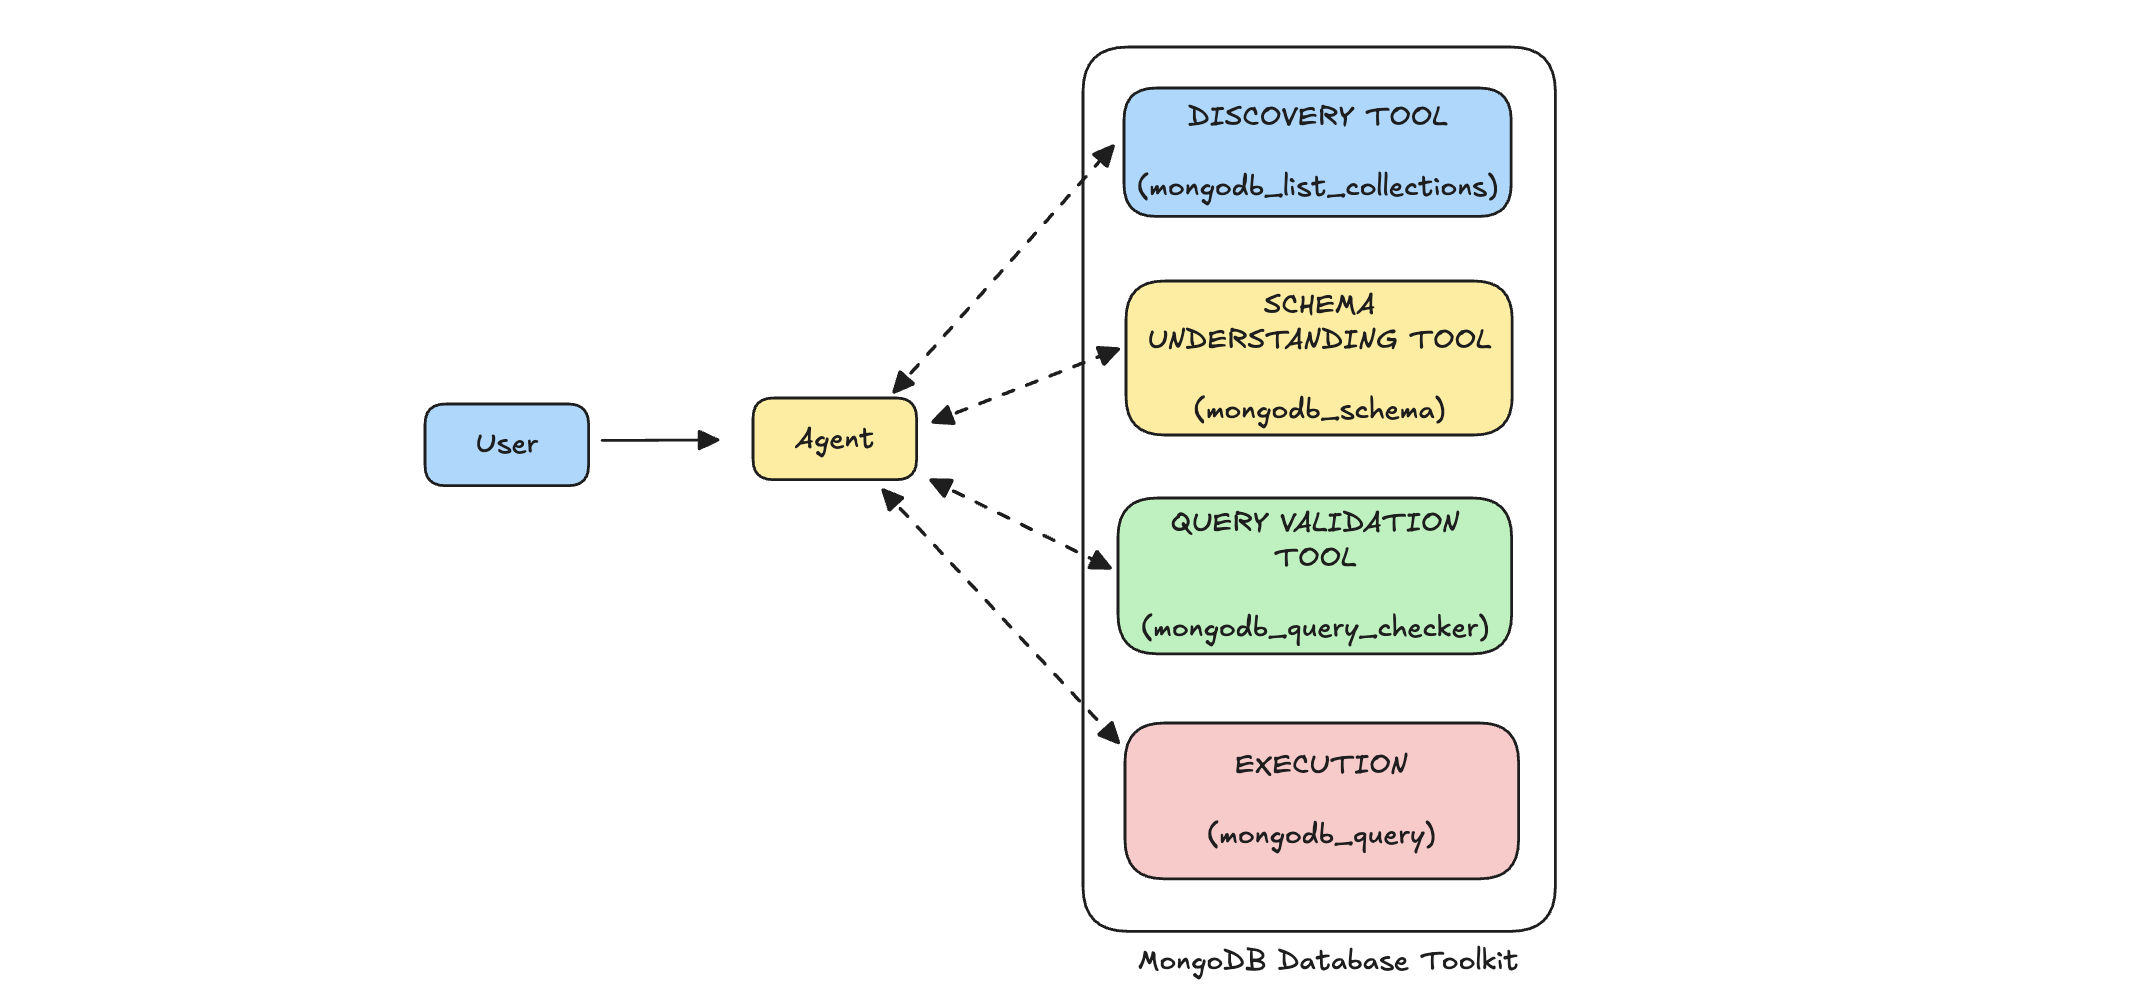

In addition to the database toolkit, the `langchain-mongodb` integration also provides a `MongoDBDatabase` class for easily accessing a MongoDB database.

Let's access the `sample_mflix` database using this class and use the resulting database object to initialize the MongoDB database toolkit.

We will use the `from_connection_string` method of the class to connect to your MongoDB cluster using the connection string you obtained previously.

In [10]:
from langchain_mongodb.agent_toolkit.database import MongoDBDatabase

MONGODB_URI = "mongodb://localhost:27017"

# Access the sample_mflix database using the MongoDBDatabase class
db = MongoDBDatabase.from_connection_string(connection_string=MONGODB_URI, database="sample_mflix")

In [11]:
db.get_usable_collection_names()

['comments', 'embedded_movies', 'movies', 'sessions', 'theaters', 'users']

**Initialize the MongoDB database toolkit and view the tools present in the toolkit using the `db` and `llm` defined previously.**

In [18]:
from langchain_mongodb.agent_toolkit.toolkit import MongoDBDatabaseToolkit
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=api_key
)

# Initialize the MongoDB database toolkit
toolkit = MongoDBDatabaseToolkit(db=db, llm=llm)

# Extract the tools from the toolkit
tools = toolkit.get_tools()

# Map tool names to tool objects
tool_map = {tool.name:tool for tool in tools}

# See what each tool does
{tool.name:tool.description for tool in tools}

{'mongodb_query': "Input to this tool is a detailed and correct MongoDB query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use mongodb_schema to query the correct collections fields.",
 'mongodb_schema': 'Input to this tool is a comma-separated list of collections, output is the schema and sample rows for those collections. Be sure that the collectionss actually exist by calling mongodb_list_collections first! Example Input: collection1, collection2, collection3',
 'mongodb_list_collections': 'Input is an empty string, output is a comma-separated list of collections in the database.',
 'mongodb_query_checker': 'Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with mongodb_query!'}

### Test the tools

Next, let's test out each of the tools in the MongoDB database toolkit. This will help us understand what the inputs and outputs of each tool look like.

In our text-to-query agent, the inputs for the tool calls are generated by an LLM but for now, let's test the tools manually.

In [22]:
# Test the mongdb_list_collections tool
tool_map['mongodb_list_collections'].invoke({})

'comments, embedded_movies, movies, sessions, theaters, users'

In [33]:
# Test the mongodb_schema_tool
print(tool_map['mongodb_schema'].invoke('theaters'), end="")

Database name: sample_mflix
Collection name: theaters
Schema from a sample of documents from the collection:
_id: ObjectId
theaterId: Number
location.address.street1: String
location.address.city: String
location.address.state: String
location.address.zipcode: String
location.geo.type: String
location.geo.coordinates: Array<Number>

/*
3 documents from theaters collection:
[
  {
    "_id": {
      "$oid": "59a47286cfa9a3a73e51e72c"
    },
    "theaterId": 1000,
    "location": {
      "address": {
        "street1": "340 W Market",
        "city": "Bloomington",
        "state": "MN",
        "zipcode": "55425"
      },
      "geo": {
        "type": "Point",
        "coordinates": [
          -93.24565,
          44.85466
        ]
      }
    }
  },
  {
    "_id": {
      "$oid": "59a47286cfa9a3a73e51e72d"
    },
    "theaterId": 1003,
    "location": {
      "address": {
        "street1": "45235 Worth Ave.",
        "city": "California",
        "state": "MD",
        "zipcode": "2

In [29]:
# Test the query checker
import json

query = [ { "$unwind": "$directors" },
          { "$group": { "_id": "$directors", "filmCount": { "$sum": 1 }, "avgRating": { "$avg": "$imdb.rating" } } },
          { "$match": { "filmCount": { "$gte": 20 } } },
          { "$sort": { "avgRating": -1 } },
          { "$limit": 5 } ]

tool_map['mongodb_query_checker'].invoke(json.dumps(query))

AIMessage(content='```json\n[{"$unwind": "$directors"}, {"$group": {"_id": "$directors", "filmCount": {"$sum": 1}, "avgRating": {"$avg": "$imdb.rating"}}}, {"$match": {"filmCount": {"$gte": 20}}}, {"$sort": {"avgRating": -1}}, {"$limit": 5}]\n```', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 178, 'total_tokens': 263, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_11f3029f6b', 'finish_reason': 'stop', 'logprobs': None}, id='run--8e55d2a5-f623-4a5b-b9c0-1b66f7d3b843-0', usage_metadata={'input_tokens': 178, 'output_tokens': 85, 'total_tokens': 263, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [32]:
# Test the mongodb_query tool
print(tool_map['mongodb_query'].invoke(f"db.movies.aggregate({json.dumps(query)}"),end="")

[
  {
    "_id": "William Wyler",
    "filmCount": 21,
    "avgRating": 7.676190476190476
  },
  {
    "_id": "Martin Scorsese",
    "filmCount": 32,
    "avgRating": 7.640625
  },
  {
    "_id": "Alfred Hitchcock",
    "filmCount": 24,
    "avgRating": 7.5874999999999995
  },
  {
    "_id": "Steven Spielberg",
    "filmCount": 29,
    "avgRating": 7.479310344827587
  },
  {
    "_id": "Woody Allen",
    "filmCount": 40,
    "avgRating": 7.215000000000001
  }
]

# Creating the text-to-query prompt

With our database tools defined, we need to make the LLM aware of these tools and how to use them. To do this, we will construct a prompt containing a clear instruction about how to use the database tools, and insert the tool names.

### Create LLM prompt

In addition to a prebuilt set of tools, the MongoDB database toolkit also provides an LLM system prompt containing instructions on how to generate MongoDB queries from natural language, and also guidance on how to use the tools available in the toolkit.

We will use this as the system prompt for the LLM in our text-to-query agent.

In [36]:
from langchain_mongodb.agent_toolkit import MONGODB_AGENT_SYSTEM_PROMPT

# Preview the system prompt
print(MONGODB_AGENT_SYSTEM_PROMPT)

You are an agent designed to interact with a MongoDB database.
Given an input question, create a syntactically correct MongoDB query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant field to return the most interesting examples in the database.
Never query for all the fields from a specific collection, only ask for the relevant fields given the question.

You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any update, insert, or delete operations.

The query MUST include the collection name and the contents of the aggregation pipeline.

An e

Notice that this system prompt takes a `top_k` variable to specify the default number of results to return. We will pre-fill this rather than it being user-specified.

In addition to the `MONGODB_AGENT_SYSTEM_PROMPT`, we will provide some more additional system instructions to the LLM. We will also need to create a placeholder to pass user messages, tool outcomes, chat history etc. to the LLM.
Let's do this using the `ChatPromptTemplate` class like we did before.

In [40]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Create a templated prompt for the LLM
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", MONGODB_AGENT_SYSTEM_PROMPT),
        ("system", "Do not re-run tools unless absolutely necessary. If you are not able to get enough information using the tools, reply with I DON'T KNOW. You have access to the following tools: {tool_names}."),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [42]:
# Pre-fill top_k and tool_names in the prompt template
prompt = prompt.partial(top_k=5, tool_names=", ".join([tool.name for tool in tools]))

In [46]:
tools[2]

ListMongoDBDatabaseTool(db=<langchain_mongodb.agent_toolkit.database.MongoDBDatabase object at 0x7f8345517310>)

In [51]:
# Bind tools to the LLM
tool_augmented_llm = llm.bind_tools(tools)

# Chain the prompt and tool-augmented LLM
llm_with_tools = prompt | tool_augmented_llm

# Test the llm with tools
# Test the llm_with_tools chain
llm_with_tools.invoke({"messages": [("user", "Give me the top 5 directors by IMDB rating, who have made more than 20 movies")]}).tool_calls

[{'name': 'mongodb_list_collections',
  'args': {},
  'id': 'call_ue4rW9McbnwoJIkr2jTSllts',
  'type': 'tool_call'}]

In [52]:
llm_with_tools.invoke({"messages": [("user", "Give me the top 5 directors by IMDB rating, who have made more than 20 movies")]})

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_siW0DEk45TwggVh6SuYyRpQJ', 'function': {'arguments': '{}', 'name': 'mongodb_list_collections'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 685, 'total_tokens': 697, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_db64b059be', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f8e6dcbb-6f23-4a60-9acb-8fc70dceed42-0', tool_calls=[{'name': 'mongodb_list_collections', 'args': {}, 'id': 'call_siW0DEk45TwggVh6SuYyRpQJ', 'type': 'tool_call'}], usage_metadata={'input_tokens': 685, 'output_tokens': 12, 'total_tokens': 697, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0

# Orchestrating the text-to-query agent

With the tools and prompt created, we are finally ready to orchestrate the text-to-query agent.

In this course, we will use LangGraph for agent orchestration. With LangGraph, you can orchestrate LLM applications as graphs. Graphs in LangGraph have three main components, namely nodes, edges and state.

Nodes help you define the main logic of the graph, edges help define the flow of the graph, and the state is a shared data structure between all the nodes.

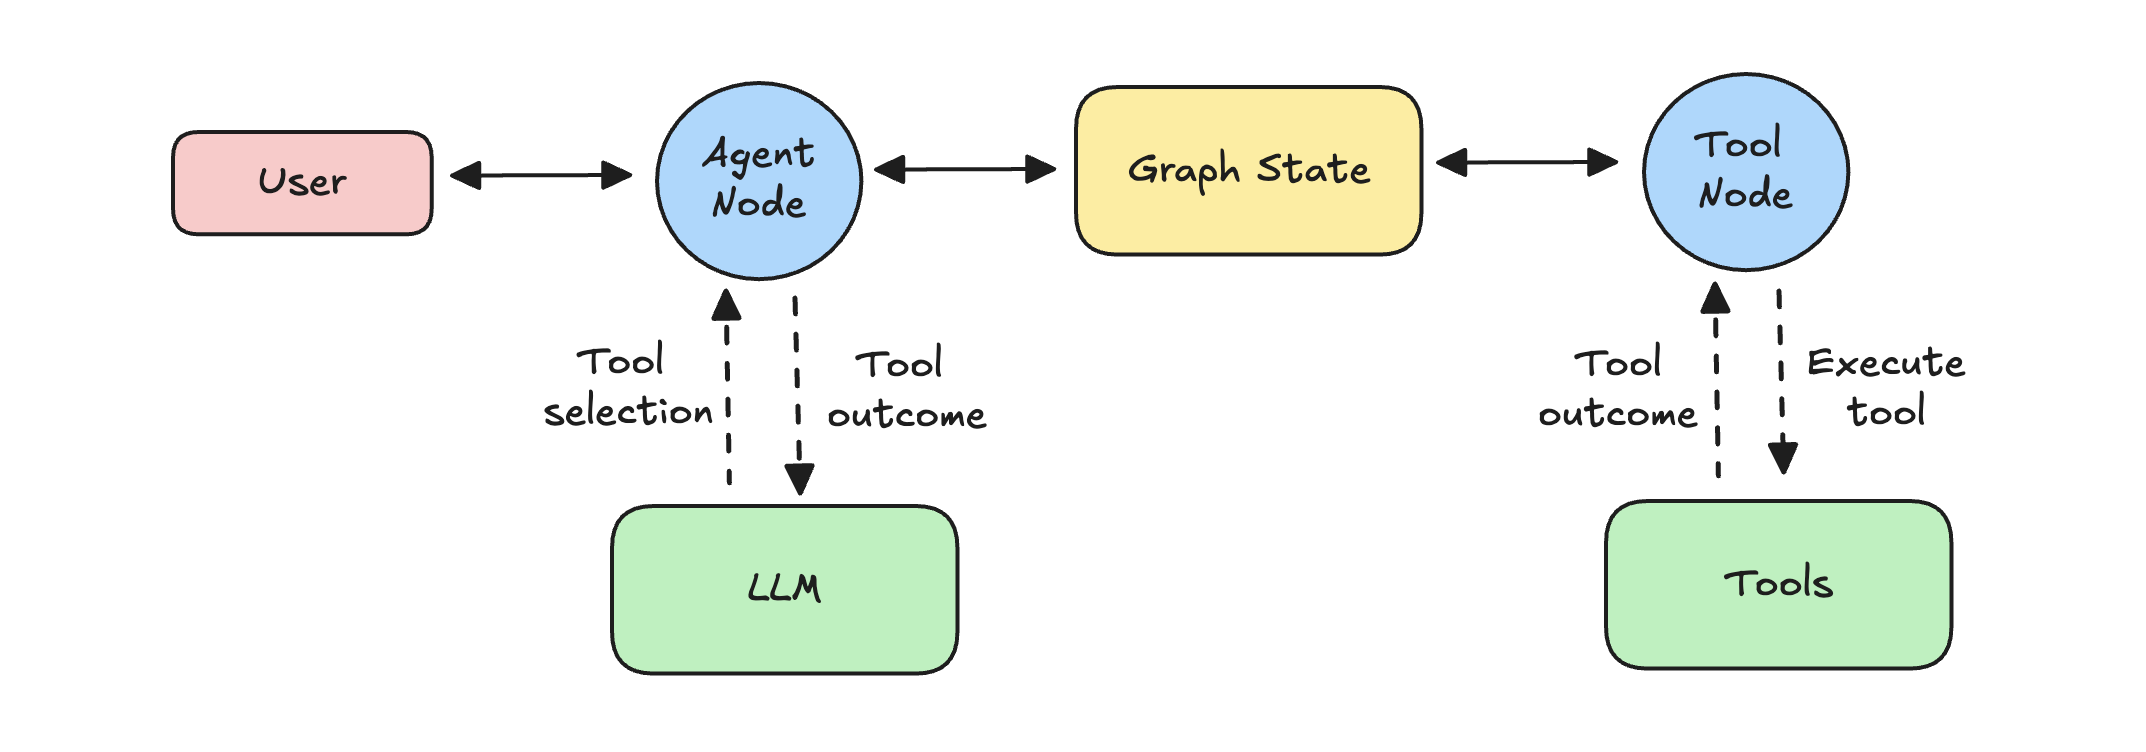


### Define graph state

First, let's define the state of our agent's graph.

To do this, we will use the `GraphState` class in LangGraph. In our case, the class will have only one attribute i.e. `messages` to track user and AI messages, but you can have additional attributes to track other information that you want the nodes in your graphs to share.

In [57]:
from typing import Annotated, List
from langgraph.graph.message import add_messages
from typing import TypedDict

class GraphState(TypedDict):
    messages: Annotated[List, add_messages]

Notice the type of the `messages` attribute: `Annotated[list, add_messages]`. This indicates that `messages` is a list and new messages are appended to it using the pre-built `add_messages` reducer function available in LangGraph.

Next, we will create the nodes of the graph, one of them being an agent node which uses a tool-augmented LLM to decide what actions to take.

However, we haven't yet given the LLM we initialized previously access the tools we created. We'd also want to give the LLM instructions on how to use these tools.

So let's do this before proceeding to create the nodes of the graph.

### Define graph nodes

Our text-to-query agent will have two nodes, an agent node, and a tool node.

Given a user query, it is first routed to the agent node which uses the tool-augmented LLM to decide the next action.

If the LLM decides to call a tool, the tool invocation payload is written to the graph's state. An example of what this looks like is as follows:
```
[{'name': 'mongodb_list_collections',
  'args': {},
  'id': 'call_qHNWqi22CP3Gqc8kdJbqv2Wy',
  'type': 'tool_call'}]
```
When the LLM decides that it has the final answer, it is also written to the graph state, and can be read from there to return to the user. We will see how later in the course.   


In [59]:
# Define the agent node
def agent_node(state):
    # Read "messages" from the graph state
    messages = state["messages"]
    # Invoke the tool-augmented LLM to determine next action
    result = llm_with_tools.invoke(messages)
    # Append the result to the graph state
    return {"messages": [result]}

In [63]:
tool_map.keys()

dict_keys(['mongodb_query', 'mongodb_schema', 'mongodb_list_collections', 'mongodb_query_checker'])

In [61]:
from langchain_core.messages import ToolMessage

# Define the tool node
def tool_node(state: GraphState):
    result = []
    # Read the tool invocation payload from the graph state
    tool_calls = state["messages"][-1].tool_calls
    for tool_call in tool_calls:
        # Extract the name of the tool to execute
        tool = tool_map[tool_call["name"]]
        # Invoke the tool with the arguments extracted from the payload
        observation = tool.invoke(tool_call["args"])
        # Create a ToolMessage to log the result of the tool execution
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    # Append the result to the graph state
    return {"messages": result}

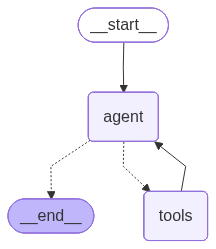

In [76]:
from langgraph.graph import START, END
from langgraph.graph import StateGraph
from langgraph.prebuilt import tools_condition

graph = StateGraph(GraphState)

# Add a node called tools that calls the agent_noddel
graph.add_node("agent", agent_node)
# Add a node called "tools" that  calls the tool_node() function
graph.add_node("tools", tool_node)

# add a fixed edge
graph.add_edge(START, "agent")
# from tools to agent
graph.add_edge("tools", "agent")
# go to tool node if agents wants to call, otherwise go to end
graph.add_conditional_edges("agent", tools_condition, {"tools":"tools",END:END})

app = graph.compile()
app

In [77]:
def execute_graph(user_input: str) -> None:
    """
    Stream outputs from the graph

    Args:
        user_input (str): User query string
    """
    # Stream outputs from each step in the graph
    for step in app.stream(
        {"messages": [{"role": "user", "content": user_input}]},
        # Stream full value of the state after each step
        stream_mode="values",
    ):
        # Print the latest message from the step
        step["messages"][-1].pretty_print()

execute_graph("Give me the top 5 directors by IMDB rating, who have made at least 20 movies")

================================ Human Message =================================

Give me the top 5 directors by IMDB rating, who have made at least 20 movies
================================== Ai Message ==================================
Tool Calls:
  mongodb_list_collections (call_jWRKBAyXVxW54TrhhPk2aovO)
 Call ID: call_jWRKBAyXVxW54TrhhPk2aovO
  Args:
================================= Tool Message =================================

comments, embedded_movies, movies, sessions, theaters, users
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (call_ZepkXUk4kLviz4RfVYSkGM3m)
 Call ID: call_ZepkXUk4kLviz4RfVYSkGM3m
  Args:
    collection_names: movies
================================= Tool Message =================================

Database name: sample_mflix
Collection name: movies
Schema from a sample of documents from the collection:
_id: ObjectId
plot: String
genres: Array<String>
runtime: Number
cast: Array<String>
poste

In [79]:
execute_graph("Find top 5 horror movies with the highest IMDB rating. Make sure the ratings are non empty.")

================================ Human Message =================================

Find top 5 horror movies with the highest IMDB rating. Make sure the ratings are non empty.
================================== Ai Message ==================================
Tool Calls:
  mongodb_list_collections (call_sFMYr7ZJ9ecmG57z0z9psizb)
 Call ID: call_sFMYr7ZJ9ecmG57z0z9psizb
  Args:
================================= Tool Message =================================

comments, embedded_movies, movies, sessions, theaters, users
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (call_Tk7AuS5iAv7BmNbJA39ODtKG)
 Call ID: call_Tk7AuS5iAv7BmNbJA39ODtKG
  Args:
    collection_names: movies
================================= Tool Message =================================

Database name: sample_mflix
Collection name: movies
Schema from a sample of documents from the collection:
_id: ObjectId
plot: String
genres: Array<String>
runtime: Number
cast: Arra

# Adding memory to the agent

In this exercise, we will add short-term memory to our text-to-query agent. Short-term memory allows AI agents to have multi-turn conversations with its users.  

In this course, we will use MongoDB to persist the agent's short-term memory. We will use MongoDB's checkpointer integration with LangGraph (`MongoDBSaver`) to automatically handle the memory management for the agent.

In [82]:
# I did not get this installed due to version conflicts and I wanted to keep it all running
# from langgraph.checkpoint.mongodb import MongoDBSaver

In [85]:
from langgraph.checkpoint.memory import MemorySaver

# create the checkpointer
checkpointer = MemorySaver()

# add the checkpointer to the graph compilation
app = graph.compile(checkpointer)

In [86]:
config = {
    "configurable": {
        "thread_id": "my-thread-001"
    }
}


In [89]:
def execute_graph_with_memory(thread_id: str, user_input: str) -> None:
  """
    Execute the memory-augmented agent

    Args:
        thread_id (str): Thread ID for which to retrieve memory
        user_input (str): User query
    """
  # Configure the thread ID
  config = {"configurable": {"thread_id": thread_id}}
  # Stream outputs from each step in the graph
  for step in app.stream(
      {"messages": [{"role": "user", "content": user_input}]},
      config,
      stream_mode="values",
  ):
      # Print the latest message from the step
      step["messages"][-1].pretty_print()

In [92]:
from uuid import uuid4 
thread_id = str(uuid4())
execute_graph_with_memory(thread_id, "Which sats have the most theaters?")

================================ Human Message =================================

Which sats have the most theaters?
================================== Ai Message ==================================
Tool Calls:
  mongodb_list_collections (call_b0AhYaVwyEUrWD4JNbwIt4Lm)
 Call ID: call_b0AhYaVwyEUrWD4JNbwIt4Lm
  Args:
================================= Tool Message =================================

comments, embedded_movies, movies, sessions, theaters, users
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (call_LD39MHfttRGZjyiEnV1qFgIG)
 Call ID: call_LD39MHfttRGZjyiEnV1qFgIG
  Args:
    collection_names: theaters
================================= Tool Message =================================

Database name: sample_mflix
Collection name: theaters
Schema from a sample of documents from the collection:
_id: ObjectId
theaterId: Number
location.address.street1: String
location.address.city: String
location.address.state: String
lo

In [93]:
execute_graph_with_memory(thread_id, "how many theaters does California have?")

================================ Human Message =================================

how many theaters does California have?
================================== Ai Message ==================================
Tool Calls:
  mongodb_query_checker (call_FVY5huUBlLyA7db1tJzlQpUe)
 Call ID: call_FVY5huUBlLyA7db1tJzlQpUe
  Args:
    query: db.theaters.aggregate([ { "$match": { "location.address.state": "CA" } }, { "$count": "totalTheaters" } ])
================================= Tool Message =================================

content='```javascript\ndb.theaters.aggregate([ { "$match": { "location.address.state": "CA" } }, { "$count": "totalTheaters" } ])\n```' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 127, 'total_tokens': 162, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},

In [97]:
config ={"configurable": {"thread_id": thread_id}}

In [99]:
import pprint

# list and analyze checkpointers
pprint.pprint(list(checkpointer.list(config, limit=1)))

[CheckpointTuple(config={'configurable': {'thread_id': 'd5b62af8-80c1-4818-b100-50d3f4e92af9', 'checkpoint_ns': '', 'checkpoint_id': '1f0d8ea8-155d-6749-8014-672fc9b0bf73'}}, checkpoint={'v': 4, 'ts': '2025-12-14T12:43:35.231857+00:00', 'id': '1f0d8ea8-155d-6749-8014-672fc9b0bf73', 'channel_versions': {'__start__': '00000000000000000000000000000017.0.8369257622076548', 'messages': '00000000000000000000000000000022.0.1805423240056504', 'branch:to:agent': '00000000000000000000000000000022.0.1805423240056504', 'branch:to:tools': '00000000000000000000000000000021.0.6159984794623451'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000016.0.2775600328033473'}, 'agent': {'branch:to:agent': '00000000000000000000000000000021.0.6159984794623451'}, 'tools': {'branch:to:tools': '00000000000000000000000000000020.0.8105047389330111'}}, 'updated_channels': ['messages'], 'channel_values': {'messages': [HumanMessage(content='Which sats have the most theaters?'

In [101]:
checkpointer.get(config)
app = graph.compile(checkpointer=checkpointer)